In [9]:
import torch
import torch.nn as nn

In [10]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs/gan')

In [11]:
device = torch.device("cpu")
# for nvidia gpu ( cuda backend )
if (torch.cuda.is_available()):
    device = torch.device("cuda")
  # mps for apple M GPU ( metal backend )
elif (torch.backends.mps.is_available()):
    device = torch.device("mps")

print("Using device:", device)

Using device: mps


In [12]:
lr_g = 1e-3
lr_d = 1e-3
batch_size = 256
epochs = 100

In [13]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

dataset_path = '../data'


mnist_transform = transforms.Compose([
    transforms.ToTensor(),
])

kwargs = {'num_workers': 1, 'pin_memory': True}

train_dataset = MNIST(
    dataset_path, transform=mnist_transform, train=True, download=True)
test_dataset = MNIST(dataset_path, transform=mnist_transform,
                     train=False, download=True)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size, shuffle=False, **kwargs)

In [14]:
import sys
sys.path.append('../')
from model import Generator, Discriminator

G = Generator(
    nn.Sequential(
        nn.Linear(784, 256),
        nn.LeakyReLU(0.2),
        nn.Linear(256, 256),
        nn.LeakyReLU(0.2),
        nn.Linear(256, 784),
        nn.Tanh()
    ),
).to(device)
D = Discriminator(
    nn.Sequential(
        nn.Linear(784, 256),
        nn.LeakyReLU(0.2),
        nn.Linear(256, 256),
        nn.LeakyReLU(0.2),
        nn.Linear(256, 1),
        nn.Sigmoid()
    ),
).to(device)

g_opt = torch.optim.Adam(G.parameters(), lr=lr_g)
d_opt = torch.optim.Adam(D.parameters(), lr=lr_d)

Generator model initialized
Discriminator model initialized


In [15]:
print("Start training GAN...")
G.train()
D.train()
BCE = nn.BCELoss().to(device)
for epoch in range(epochs):
    overall_loss_g = 0
    overall_loss_d = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        batch_size = x.size(0)
        x = x.view(batch_size, 784)
        x = x.to(device)
        real_label = torch.ones(batch_size, 1).to(device)
        fake_label = torch.zeros(batch_size, 1).to(device)  
        noise = torch.randn(batch_size, 784).to(device)
        # Train Discriminator
        D.zero_grad()
        real_output = D(x)
        fake_output = D(G(noise))
        d_loss_real = BCE(real_output, real_label)
        d_loss_fake = BCE(fake_output, fake_label)
        d_loss = d_loss_real + d_loss_fake
        overall_loss_d += d_loss.item()
        d_loss.backward()
        d_opt.step()

        # Train Generator
        G.zero_grad()
        noise = torch.randn(batch_size, 784).to(device)
        fake_output = D(G(noise))
        g_loss = BCE(fake_output, real_label)
        overall_loss_g += g_loss.item()
        g_loss.backward()
        g_opt.step()
    print(f"Epoch {epoch+1}/{epochs} Loss D: {overall_loss_d/len(train_loader):.6f} Loss G: {overall_loss_g/len(train_loader):.6f}")
    

Start training GAN...
Epoch 1/100 Loss D: 0.573216 Loss G: 12.750344
Epoch 2/100 Loss D: 0.959340 Loss G: 5.280809
Epoch 3/100 Loss D: 1.194863 Loss G: 4.389327
Epoch 4/100 Loss D: 1.296561 Loss G: 3.079520
Epoch 5/100 Loss D: 1.277286 Loss G: 2.204789
Epoch 6/100 Loss D: 1.156377 Loss G: 2.029407
Epoch 7/100 Loss D: 1.395130 Loss G: 1.400138
Epoch 8/100 Loss D: 1.345202 Loss G: 4.345171
Epoch 9/100 Loss D: 1.227705 Loss G: 3.274382
Epoch 10/100 Loss D: 1.182394 Loss G: 2.287326
Epoch 11/100 Loss D: 1.278344 Loss G: 1.803444
Epoch 12/100 Loss D: 1.420349 Loss G: 2.475244
Epoch 13/100 Loss D: 1.324923 Loss G: 2.656654
Epoch 14/100 Loss D: 1.337531 Loss G: 1.424088
Epoch 15/100 Loss D: 1.359560 Loss G: 1.659322
Epoch 16/100 Loss D: 1.453532 Loss G: 2.349838
Epoch 17/100 Loss D: 1.377764 Loss G: 1.651572
Epoch 18/100 Loss D: 1.355644 Loss G: 1.319975
Epoch 19/100 Loss D: 1.304050 Loss G: 2.598990
Epoch 20/100 Loss D: 1.269868 Loss G: 2.550876
Epoch 21/100 Loss D: 1.302828 Loss G: 2.739422

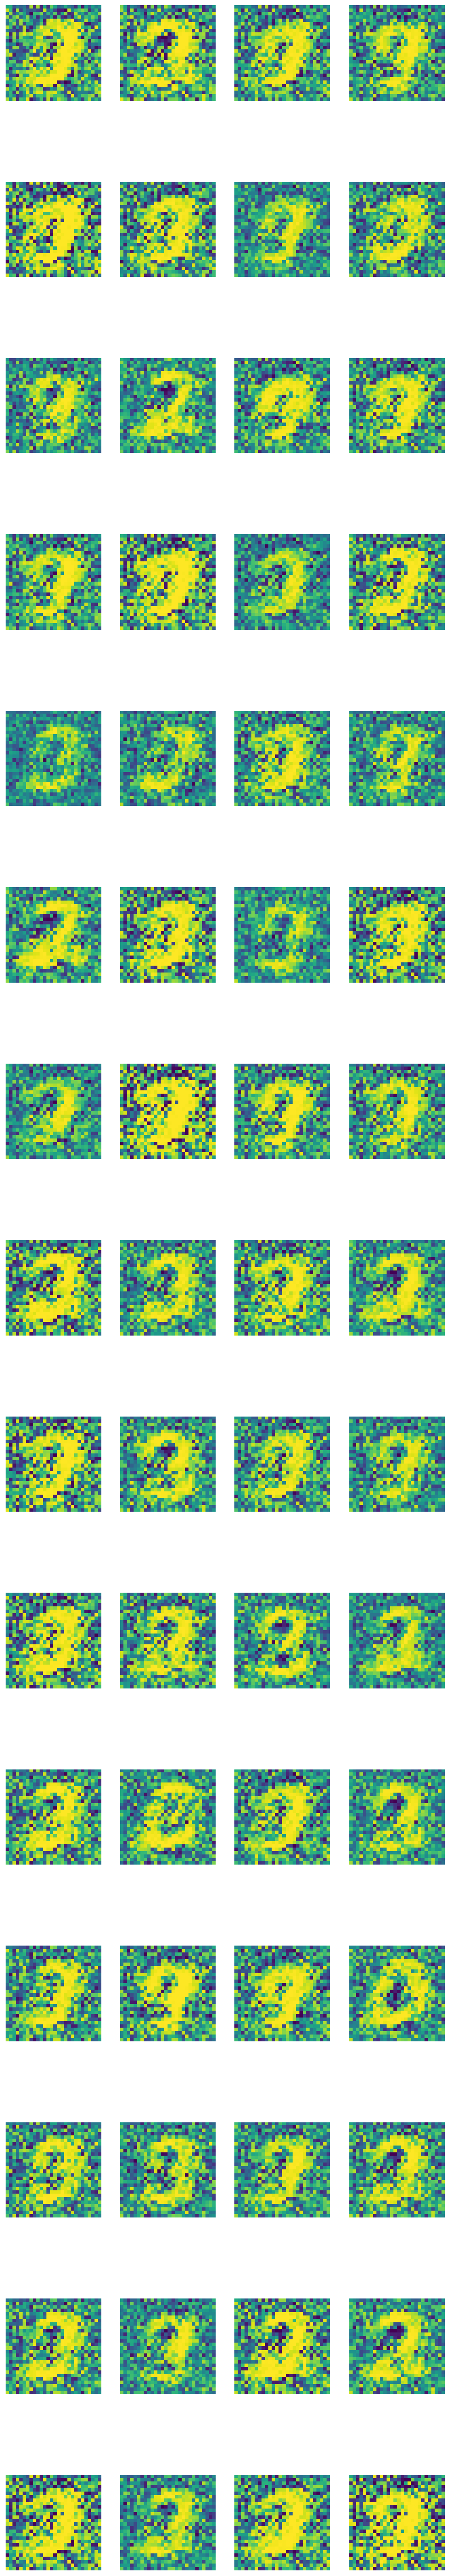

In [19]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=15, ncols=4, figsize=(10, 60))


G.eval()
with torch.no_grad():
    noise = torch.randn(64, 784).to(device)
    fake = G(noise).view(-1, 1, 28, 28)
    for i in range(15):
        for j in range(4):
            axes[i, j].imshow(fake[i*4+j].cpu().numpy().reshape(28, 28),)
            axes[i, j].axis('off')
    
